# Dimensionality Reduction

This notebook implements the **Dimensionality Reduction** stage of the CRISP-DM methodology for the *Mental Health in Technology* project.

Notebook 02 converted the raw OSMI Mental Health in Tech 2016 survey into a reproducible numerical analytical matrix. The resulting representation contains 1,433 respondents and a substantially larger number of encoded features than the original survey because nominal categorical responses have been represented using one-hot encoding and the multi-response work-position field has been decomposed into binary indicators.

This notebook therefore does **not repeat data cleaning, feature engineering, imputation, or categorical encoding**. It begins from the processed analytical dataset created in Notebook 02.

Dimensionality reduction is investigated because a high-dimensional representation can make subsequent distance-based analysis and clustering more difficult to interpret. The objective is not simply to produce the smallest possible representation, but to determine whether a lower-dimensional representation can preserve meaningful structure while remaining suitable for the clustering experiments that follow.

The analysis focuses on:

- assessing the structure of the prepared feature space;
- evaluating **Principal Component Analysis (PCA)** as the primary dimensionality-reduction method;
- examining explained variance and component loadings;
- evaluating **Multidimensional Scaling (MDS)** as a complementary distance-based representation;
- considering **Locally Linear Embedding (LLE)** only where its use is methodologically justified;
- retaining the representations required for the subsequent clustering experiments.

The dimensionality-reduction results are therefore treated as analytical inputs to the clustering stage rather than as a final model selection decision.

No clustering model is fitted in this notebook.

## 1. Dimensionality-Reduction Objectives

### Question

Can the prepared analytical feature space be represented in substantially fewer dimensions while retaining meaningful structure for subsequent unsupervised analysis?

### Method

The analysis proceeds in stages:

1. Load and validate the canonical analytical matrix produced by Notebook 02.
2. Establish the dimensionality of the prepared feature space.
3. Evaluate the variance structure using PCA.
4. Examine the contribution of the leading principal components.
5. Determine a PCA representation using the observed variance structure rather than an arbitrary fixed number of components.
6. Evaluate MDS as a complementary representation based on pairwise distances.
7. Assess whether LLE is sufficiently justified for inclusion.
8. Preserve the resulting representations for comparison during the clustering stage.

### Why

Dimensionality reduction changes the geometry of the feature space used by later clustering algorithms. The decision must therefore be evidence-based.

A useful reduced representation should reduce dimensionality without discarding the dominant structure of the prepared data or creating an artificial representation that is difficult to interpret.

The dimensionality-reduction stage consequently informs, but does not replace, the clustering evaluation performed in Notebook 04.

In [7]:
# Import the libraries required for loading the prepared analytical matrix,
# dimensionality-reduction experiments, and diagnostic visualizations.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

## 2. Load the Prepared Analytical Matrix

Notebook 02 produced the canonical processed analytical dataset:

`data/processed/mental_health_prepared.csv`

This file contains the numerical representation that resulted from the documented preparation decisions.

Loading this artifact instead of rebuilding the preparation pipeline keeps the CRISP-DM stages separate and makes the transition between notebooks reproducible.

In [8]:
# Load the canonical analytical matrix produced by the Data Preparation stage.
processed_path = Path("../data/processed/mental_health_prepared.csv")

X_prepared = pd.read_csv(
    processed_path,
    index_col=0,
)

print(
    "Prepared analytical matrix loaded: "
    f"{X_prepared.shape[0]:,} observations x "
    f"{X_prepared.shape[1]} features."
)

Prepared analytical matrix loaded: 1,433 observations x 495 features.


## 3. Analytical Input Validation

### Question

Does the processed dataset satisfy the structural requirements for dimensionality-reduction analysis?

### Validation criteria

The analytical input must:

- contain the same respondent count established during data preparation;
- contain only numerical features;
- contain no remaining missing values;
- contain only finite values.

These checks validate the handoff from Notebook 02. They do not repeat the preparation analysis itself.

In [9]:
# Validate the structural properties required before dimensionality reduction.
if X_prepared.shape[0] != 1433:
    raise ValuerError(
        f"Unexpected respondent count: {X_prepared.shape[0]}. "
        "Expected 1,433 observations."
    )

if not all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in X_prepared.dtypes
):
    raise TypeError(
        "The prepared analytical matrix must contain only numerical features."
    )

if X_prepared.isna().any().any():
    raise ValueError(
        "The prepared analytical matrix contains missing values."
    )

if not np.isfinite(X_prepared.to_numpy()).all():
    raise ValueError(
        "The prepared analytical matrix contains non-finite values."
    )

print(
    "Analytical input validation passed: "
    f"{X_prepared.shape[0]:,} observations and "
    f"{X_prepared.shape[1]} finite numerical features."
)

Analytical input validation passed: 1,433 observations and 495 finite numerical features.


## 4. Starting Feature Space

The prepared analytical matrix is the result of the representation decisions established in Notebook 02.

Its dimensionality is recorded here as the baseline against which dimensionality reduction will be assessed.

The purpose of this step is descriptive rather than exploratory: the feature space has already been prepared and validated. The question now is how effectively its structure can be represented using fewer dimensions.

In [10]:
# Record the dimensionality that dimensionality-reduction methods must address.
original_observations, original_features = X_prepared.shape

print(
    "Starting analytical space: "
    f"{original_observations:,} observations x "
    f"{original_features} features."
)

Starting analytical space: 1,433 observations x 495 features.


## 5. Feature Scaling for Dimensionality Reduction

### Question

Should the prepared numerical features be placed on a comparable scale before PCA?

### Evidence

The prepared analytical matrix contains heterogeneous numerical representations. It includes the continuous age variable together with binary and one-hot encoded indicators.

PCA is variance-based. Consequently, variables with larger numerical variance can contribute disproportionately to the principal components if the features are entered on their original scales.

The prepared matrix was intentionally left unscaled in Notebook 02 because scaling was treated as a modelling and representation decision rather than as part of data cleaning.

### Decision

Standardization is therefore evaluated explicitly at this stage rather than being hidden inside the preparation pipeline.

Each feature is transformed to have approximately zero mean and unit variance before PCA.

This keeps the dimensionality-reduction decision visible and reproducible while preventing the continuous age variable from receiving disproportionate influence solely because of its numerical scale.

In [11]:
# Standardize the prepared features so that PCA evaluates their structure
# on a comparable variance scale rather than according to their original units.
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_prepared),
    columns=X_prepared.columns,
    index=X_prepared.index,
)

print(
    "Standardized analytical matrix: "
    f"{X_scaled.shape[0]:,} observations x "
    f"{X_scaled.shape[1]} features."
)

Standardized analytical matrix: 1,433 observations x 495 features.


### Interpretation

Standardization changes the numerical geometry supplied to PCA, but it does not change the respondent count or the underlying feature definitions.

The standardized matrix is therefore used as the PCA input. The original processed matrix remains available as the unscaled reference representation.

This distinction is important because scaling is part of the analytical representation being evaluated, not a correction to the underlying survey data.

## 6. Principal Component Analysis

### Question

How much of the standardized feature-space variation can be represented by a substantially smaller number of principal components?

### Method

PCA is first fitted with all available components.

This provides the complete explained-variance profile before any reduced representation is selected. The resulting component structure is then examined using:

- individual explained variance;
- cumulative explained variance;
- the rate at which additional components contribute information.

### Why

PCA provides a quantitative basis for determining whether the high-dimensional feature space contains substantial lower-dimensional structure.

The purpose is not to force a predetermined number of components, but to use the observed variance structure to identify a defensible reduced representation for later comparison during clustering.

In [12]:
# Fit PCA across the complete standardized feature space so that the full
# explained-variance structure can be examined before reducing dimensions.
pca_full = PCA()

pca_full.fit(X_scaled)

pca_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": (
            pca_full.explained_variance_ratio_.cumsum()
        ),
    }
)

pca_variance.head()

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.066792,0.066792
1,2,0.030243,0.097035
2,3,0.022211,0.119246
3,4,0.016189,0.135435
4,5,0.013117,0.148552


## 7. PCA Explained Variance

The explained-variance profile provides the primary evidence for assessing the extent to which the prepared feature space can be represented using fewer dimensions.

Two complementary views are used:

1. the variance contribution of individual components;
2. the cumulative variance represented as components are added.

The cumulative profile is particularly important because it shows how many components are required to retain progressively larger proportions of the variance in the standardized feature space.

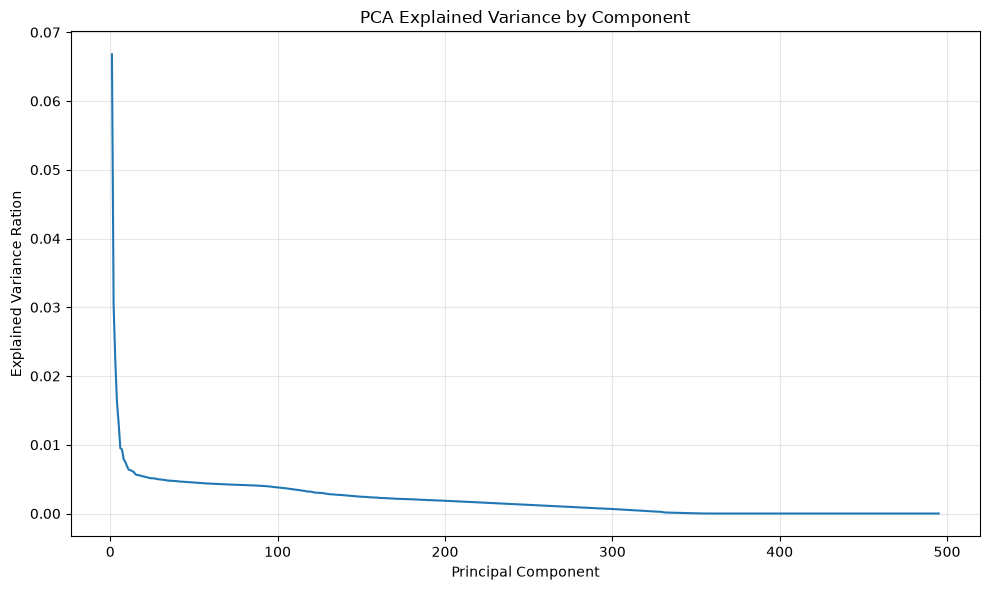

In [13]:
# Visualize the contribution of individual principal components.
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=pca_variance,
    x="component",
    y="explained_variance_ratio",
    ax=ax,
)

ax.set(
    title="PCA Explained Variance by Component",
    xlabel="Principal Component",
    ylabel="Explained Variance Ration",
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

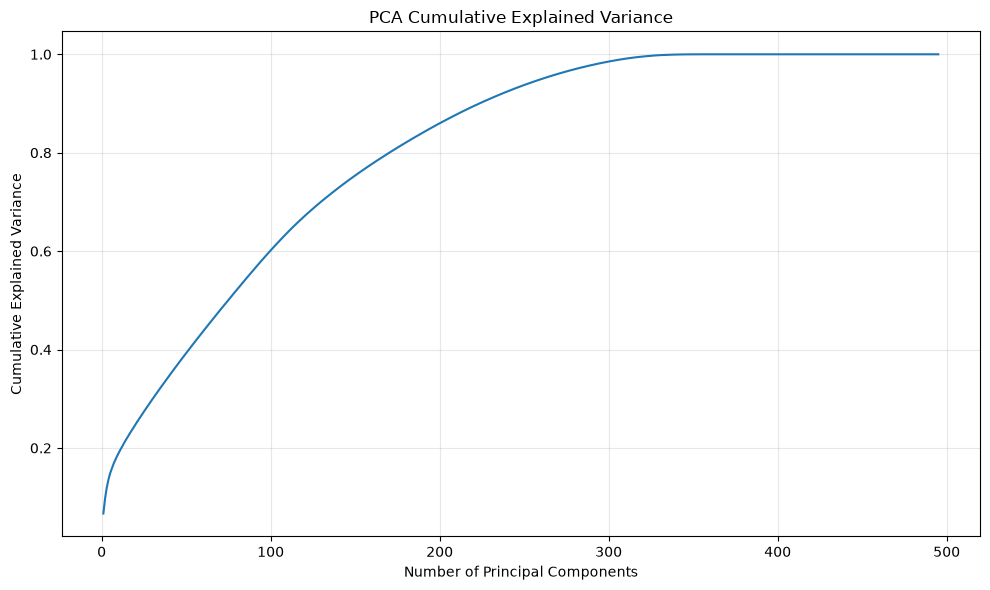

In [14]:
# Visualize the cumulative variance retained retained as additional components are included.
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=pca_variance,
    x="component",
    y="cumulative_explained_variance",
    ax=ax,
)

ax.set(
    title="PCA Cumulative Explained Variance",
    xlabel="Number of Principal Components",
    ylabel="Cumulative Explained Variance",
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Report useful cumulative-variance reference points so that the PCA
# representation can be selected from the observed data structure.
variance_thresholds = pd.DataFrame(
    {
        "variance_threshold": [0.70, 0.80, 0.90, 0.95],
        "components_required": [
            int(
                np.searchsorted(
                    pca_variance["cumulative_explained_variance"].to_numpy(),
                    threshold,
                )
                + 1
            )
            for threshold in [0.70, 0.80, 0.90, 0.95]
        ],
    }
)

variance_thresholds

,variance_threshold,components_required
0,0.70,130
1,0.80,171
2,0.90,224
3,0.95,261


### Interpretation

The variance-threshold table quantifies how quickly the high-dimensional feature space can be represented with fewer principal components.

These thresholds are **diagnostic reference points**, not independent modelling rules. The final clustering experiments will determine whether the selected PCA representation preserves useful cluster structure.

The important evidence from this stage is therefore the relationship between the original feature count and the number of components required to retain substantial cumulative variance.

A large reduction in dimensionality with substantial retained variance provides empirical support for using PCA as a candidate clustering representation.

## 8. Principal Component Loadings

### Question

What types of prepared features contribute most strongly to the leading principal components?

### Why

Explained variance alone does not establish interpretability. Examining component loadings provides a connection between the mathematical transformation and the original survey representation.

The leading components are therefore inspected to identify the features with the largest absolute contributions.

Only the strongest loadings are displayed to keep the interpretation focused rather than producing an exhaustive list of encoded variables.

In [17]:
# Convert PCA component coefficients into a traceable feature-level table.
pca_loadings = pd.DataFrame(
    pca_full.components_,
    columns=X_scaled.columns,
    index=[
        f"PC{i}"
        for i in range(1, pca_full.n_components_ + 1)
    ],
)

# Identify the strongest absolute loadings across the first five components.
leading_loadings = (
    pca_loadings.iloc[:5]
    .T
    .assign(
        maximum_absolute_loading=lambda data: data.abs().max(axis=1)
    )
    .sort_values(
        "maximum_absolute_loading",
        ascending=False,
    )
)

leading_loadings.head(20)

,PC1,PC2,PC3,PC4,PC5,maximum_absolute_loading
categorical__Were you aware of the options for mental health care provided by your previous employers?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Did your previous employers provide resources to learn more about mental health issues and how to seek help?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Have your previous employers provided mental health benefits?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Do you think that discussing a physical health issue with previous employers would have negative consequences?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Do you think that discussing a mental health disorder with previous employers would have negative consequences?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Would you have been willing to discuss a mental health issue with your previous co-workers?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Did you feel that your previous employers took mental health as seriously as physical health?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805
categorical__Would you have been willing to discuss a mental health issue with your direct supervisor(s)?_Missing,0.006185,0.253805,0.045339,-0.020878,0.010549,0.253805


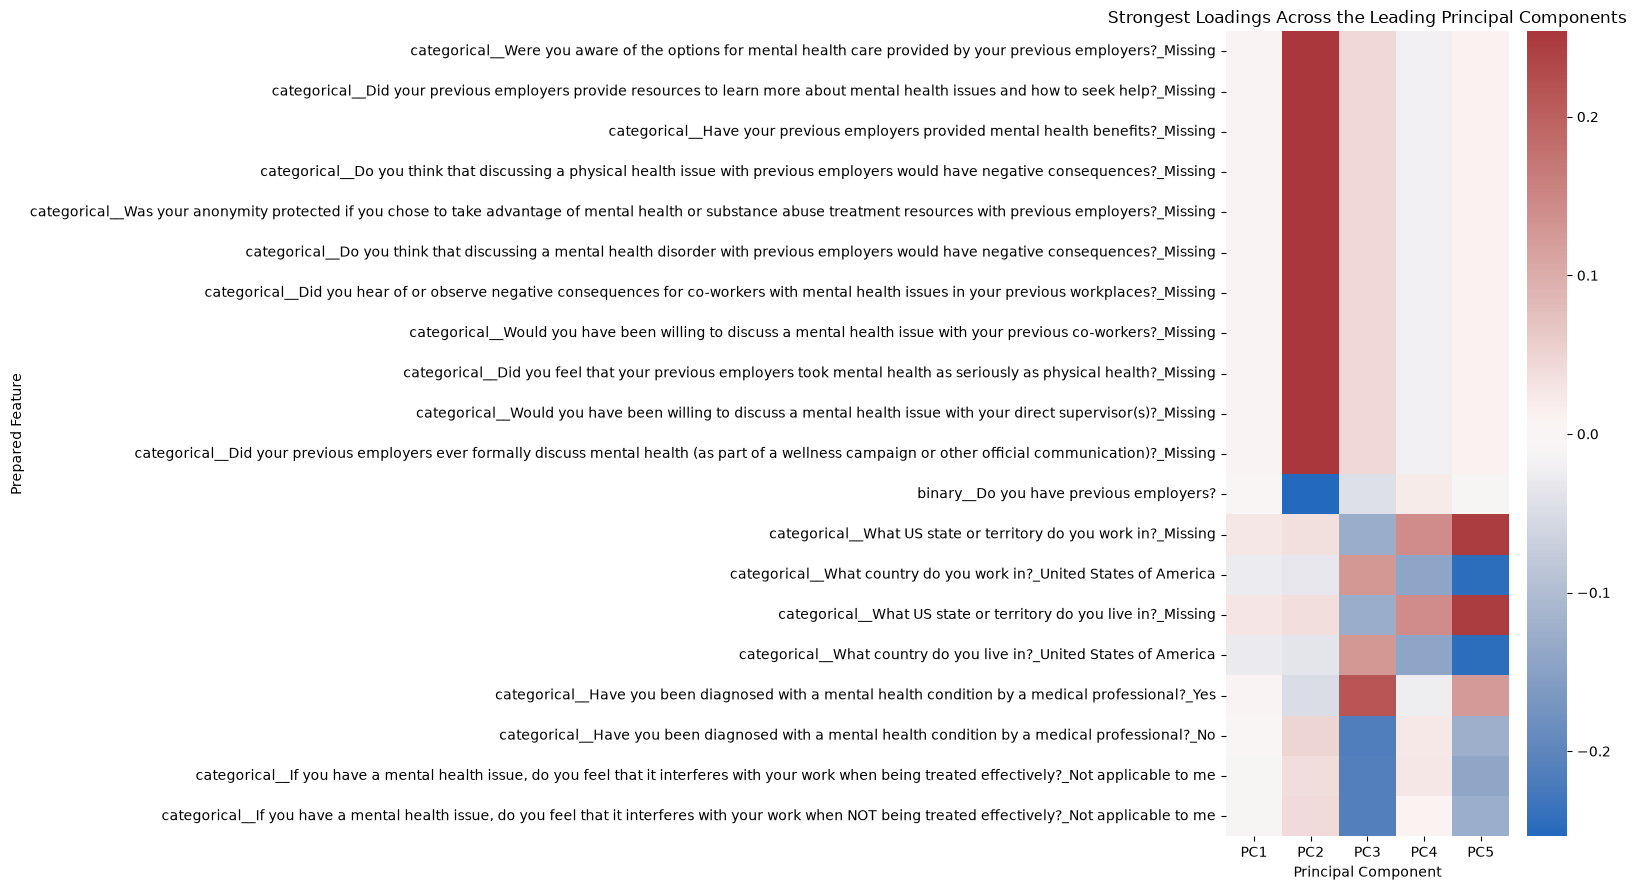

In [20]:
# Visualize only the strongest features contributing to the leading components.
loading_matrix = leading_loadings.head(20).drop(
    columns="maximum_absolute_loading"
)

fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    loading_matrix,
    cmap="vlag",
    center=0,
    ax=ax,
)

ax.set(
    title="Strongest Loadings Across the Leading Principal Components",
    xlabel="Principal Component",
    ylabel="Prepared Feature",
)

plt.tight_layout()
plt.show()

### Interpretation

The loading analysis provides a second layer of evidence beyond explained variance.

Features with large positive or negative loadings contribute strongly to the corresponding principal component. Because the prepared matrix contains encoded survey variables, the components should be interpreted as combinations of related response patterns rather than as individual survey questions.

The leading components are therefore useful as transformed representations of the original feature space, but their interpretation must remain grounded in the underlying survey variables.

The PCA representation will be carried forward as the **primary reduced representation**. Its dimensionality is determined from the observed explained-variance structure and will subsequently be evaluated through the clustering experiments rather than being declared optimal solely from PCA variance retention.